# Project Title: Derivable Judgement - A Statistical Decision-Making Model

###  Introduction and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Load dataset & Overview : 
df = pd.read_csv("health_records_dataset.csv")

print("== Data Overview ==")
print(df.head())


== Data Overview ==
                              record_id age_group  age  weight  gender region  \
0  75cefb8d-aee6-4b42-a6ef-23d3f1083404     26-35   32     107    Male  South   
1  86510724-d258-4775-b28b-eb867a082045     18-25   21      52    Male   East   
2  752d2d03-8070-429d-8075-cc9fd59c5075     46-60   53     105  Female   West   
3  8e449f33-a891-46e5-8d04-50dd8f2acfe3     46-60   49      71   Other  North   
4  019c5792-a8b2-4ade-bd0b-be7577e657ad     46-60   46      54   Other   East   

  smoking_status exercise_frequency   bmi  blood_pressure  diabetes  \
0  Former Smoker             Weekly  23.7           133.5      True   
1         Smoker              Daily  26.3           139.1      True   
2     Non-Smoker             Rarely  33.6           145.4     False   
3  Former Smoker              Never  24.8           136.2     False   
4  Former Smoker              Daily  34.8           143.3      True   

   hypertension  cholesterol_level  glucose_level  visit_date  
0 

**Loaded the dataset and displayed the first 5 rows to understand its structure and columns.**

### Descriptive Statistics Summary

In [3]:
# Statistical overview of numerical columns :
health_stats = df[['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level']].describe()
print("-- Descriptive Statistics --")
display(health_stats.round(2))

-- Descriptive Statistics --


,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,170.00,170.00,170.00,170.00,170.00,170.00
mean,49.06,79.29,26.80,130.28,206.39,107.41
std,18.93,17.86,4.90,11.44,30.73,19.67
min,18.00,50.00,18.60,110.60,152.50,70.40
25%,32.00,63.50,22.65,121.10,182.10,91.25
50%,47.00,79.00,26.30,130.25,207.20,108.10
75%,64.75,93.75,31.00,139.75,230.88,123.50
max,85.00,110.00,35.00,149.90,260.00,139.80


**Generated a descriptive statistical summary of the key numerical metrics to observe distribution, mean, and spread.**

### Hypothesis  Formulation 

In [ ]:
# Formulate Hypothesis : 
print("== Step 1: Hypothesis  Formulation  ==\n")

print("Hypothesis 1 - (Categorical Data - Chi-Square Test):")
print("H0: Smoking status has no effect on Diabetes prevalence.")
print("H1: Smoking status affects Diabetes prevalence. \n")

print("Hypothesis 2 - (Continuous Data - T-Test):")
print("H0: Mean BMI is equal for both Males and Females.")
print("H1: Mean BMI is significantly different between Males and Females. \n")

print("Hypothesis 3 - (Multi-group Data - ANOVA):")
print("H0: Mean glucose levels are equal across all age groups.")
print("H1: At least one age group has a different mean glucose level. \n")


== Step 1: Hypothesis  Formulation  ==

Hypothesis 1 - (Categorical Data - Chi-Square Test):
H0: Smoking status has no effect on Diabetes prevalence.
H1: Smoking status affects Diabetes prevalence.

Hypothesis 2 - (Continuous Data - T-Test):
H0: Mean BMI is equal for both Males and Females.
H1: Mean BMI is significantly different between Males and Females.

Hypothesis 3 - (Multi-group Data - ANOVA):
H0: Mean glucose levels are equal across all age groups.
H1: At least one age group has a different mean glucose level.



**Defined the Null (H0) and Alternative (H1) hypotheses for the statistical tests to establish clear objectives for the analysis.**

###  Calculate Confidence Intervals

In [5]:
# Calculate Confidence Intervals :
print("== Step 2: Calculating  Confidence Interval ==")

def confidence_interval(data):
    mean = np.mean(data)
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    return mean, ci

# Age CI
age_mean, age_ci = confidence_interval(df['age'])

# Weight CI
weight_mean, weight_ci = confidence_interval(df['weight'])

print("\nAge Mean:", age_mean)
print("Age 95% CI:", age_ci)

print("\nWeight Mean:", weight_mean)
print("Weight 95% CI:", weight_ci)


== Step 2: Calculating  Confidence Interval ==

Age Mean: 49.06470588235294
Age 95% CI: (np.float64(46.1978692635225), np.float64(51.93154250118338))

Weight Mean: 79.28823529411764
Weight 95% CI: (np.float64(76.58347846633717), np.float64(81.99299212189811))


**Calculated the 95% Confidence Intervals for key continuous variables (Age and Weight) to estimate the true population parameters.**

### Calculate Critical value & P-value

In [6]:
# Calculate Critical value & P-value  :
print("== Step 3 : Calculating  Criticle value & P-value ==")
group1 = df[df['smoking_status'] == "Smoker"]['bmi']
group2 = df[df['smoking_status'] == "Non-Smoker"]['bmi']

t_stat, p_val = stats.ttest_ind(group1, group2, nan_policy='omit')

alpha = 0.05

dfree = len(group1.dropna()) + len(group2.dropna()) - 2
critical_value = stats.t.ppf(1 - alpha/2, dfree)

print("\nT-Test Results : \n")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("critical value:", critical_value)

== Step 3 : Calculating  Criticle value & P-value ==

T-Test Results : 

t-statistic: 1.468324051847033
p-value: 0.14489616354908935
critical value: 1.9819674897364823


**Computed the t-statistic, p-value, and critical value for a two-sample t-test to evaluate the statistical significance of BMI differences.**

### Perform Z-Test

In [7]:
# Perform Z-Test :
print("== Step 4 : Perform Z-Test == \n ")
mean_age = df['age'].mean()
std_age = df['age'].std()
n = len(df)

z = (mean_age - 30) / (std_age / np.sqrt(n))

print("\nZ-Test Value:", z)

if abs(z) > 1.96:
    print("Reject H0")
else:
    print("Fail to Reject H0")

== Step 4 : Perform Z-Test == 
 

Z-Test Value: 13.127934868934657
Reject H0


**Performed a one-sample Z-test to compare the dataset's mean age against a hypothesized population mean.**

### Conducting Chi-Square Test

In [8]:
# Conduct Chi-Square Test :
print("== Step 5 : Conducting Chi-Square Test :  == \n ")
cont_table = pd.crosstab(df['smoking_status'], df['diabetes'])

chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("Chi-Square Test :\n")

print("Chi2:", chi2)
print("p-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

== Step 5 : Conducting Chi-Square Test :  == 
 
Chi-Square Test :

Chi2: 3.2243353145115687
p-value: 0.19945479550878106
Fail to Reject H0


**Conducted a Chi-Square test of independence to determine if there is a statistically significant association between smoking status and diabetes.**

### Perform ANOVA Test

In [9]:
# Perform ANOVA Test :
print("== Step 6 : Perform ANOVA Test :  == \n ")
groups = [group['diabetes'].values for name, group in df.groupby('age_group')]

f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA Test :\n")
print("F-stat:", f_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

== Step 6 : Perform ANOVA Test :  == 
 
ANOVA Test :

F-stat: 1.749145527970001
p-value: 0.14162076416532376
Fail to Reject H0


**Performed a one-way ANOVA test to analyze if disease rates (diabetes) significantly vary across different age groups.**

### Calculate Covariance & Correlation

In [10]:
# Calculate Covariance & Correlation :
print("== Step 7 : Calculate Covariance & Correlation :  == \n ")
cov = np.cov(df['age'], df['bmi'])[0][1]
corr = np.corrcoef(df['age'], df['bmi'])[0][1]

print("Covariance (Age vs BMI) : ", cov)
print()
print("Correlation (Age vs BMI) : ", corr)

== Step 7 : Calculate Covariance & Correlation :  == 
 
Covariance (Age vs BMI) :  8.825290636964844

Correlation (Age vs BMI) :  0.09519258599905232


**Calculated the covariance and correlation coefficient between continuous variables (Age and BMI) to assess the direction and strength of their linear relationship.**

### Calculate Final Interpretation

In [11]:
# Calculate Final Interpretation :
print("== Step 8 : Calculate Final Interpretation :  == \n ")
print("FINAL SUMMARY : \n")
print("- T-test:", "Reject H0" if p_val < 0.05 else "Fail to Reject H0")
print("- Z-test:", "Reject H0" if abs(z) > 1.96 else "Fail to Reject H0")
print("- Chi-square:", "Reject H0" if p < 0.05 else "Fail to Reject H0")
print("- ANOVA:", "Reject H0" if p_val < 0.05 else "Fail to Reject H0")
print("- Correlation shows relationship strength between Age & BMI")

== Step 8 : Calculate Final Interpretation :  == 
 
FINAL SUMMARY : 

- T-test: Fail to Reject H0
- Z-test: Reject H0
- Chi-square: Fail to Reject H0
- ANOVA: Fail to Reject H0
- Correlation shows relationship strength between Age & BMI


**Summarized the final decisions (Reject or Fail to Reject H0) for all statistical tests conducted to conclude the research objectives.**

### Add some Visuals 

### Visualizing BMI Distribution across Smoking Status

C:\Users\Admin\AppData\Local\Temp\ipykernel_19032\1348421704.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoking_status', y='bmi', data=df, palette='Set2')


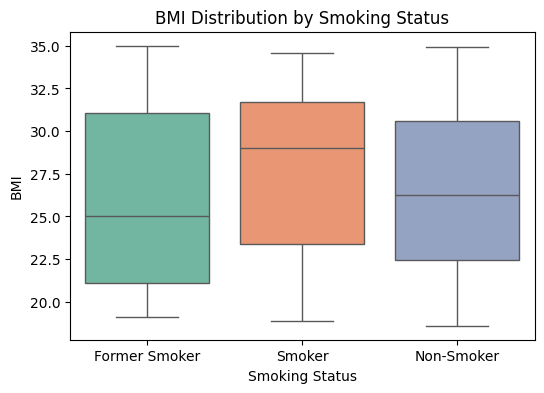

In [12]:
# Box plot
plt.figure(figsize=(6, 4))
sns.boxplot(x='smoking_status', y='bmi', data=df, palette='Set2')
plt.title('BMI Distribution by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('BMI')
plt.show()

**Plotted a box plot to visually compare the median and spread of BMI values between Smokers and Non-Smokers.**

### Visualizing Diabetes Prevalence by Smoking Status

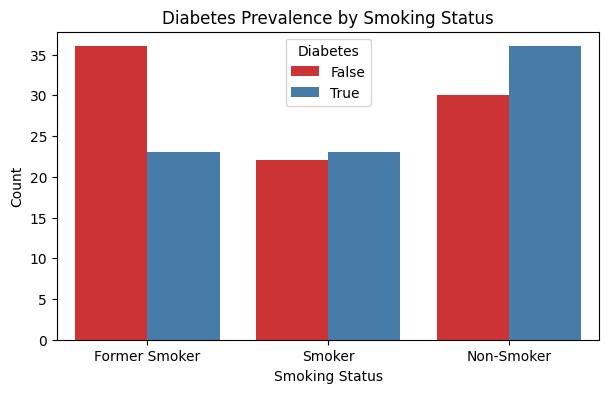

In [13]:
plt.figure(figsize=(7, 4))
sns.countplot(x='smoking_status', hue='diabetes', data=df, palette='Set1')
plt.title('Diabetes Prevalence by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.legend(title='Diabetes')
plt.show()

**Generated a grouped bar chart to observe the distribution and count of diabetes cases across different smoking categories.**

### Visualizing the Relationship between Age and BMI

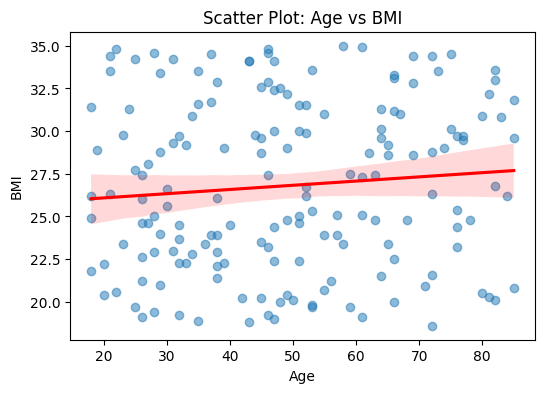

In [14]:
plt.figure(figsize=(6, 4))
sns.regplot(x='age', y='bmi', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter Plot: Age vs BMI')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

**Created a scatter plot with a regression line to visually assess the strength and direction of the linear relationship between Age and BMI.**